# Técnicas Clásicas de Visión
| IA 5.2 Computer Vision   
| FCEIA - UNR

En este cuaderno se desarrollan ejercicios relacionados a la calse 2 "Técnicas clásicas de Visión" de la materia.

# Librerías a utilizar

In [2]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Detección de bordes

La detección de bordes es una herramienta fundamental que usan internamente los modelos para poder obtener features de las imágenes / objetos a clasificar / detectar.

## Filtro sobel



> "El operador Sobel es un ejemplo clásico de un detector de características basado en la convolución. No utiliza un solo filtro, sino un par de kernels de 3×3 diseñados para trabajar en conjunto. Su propósito es calcular una aproximación del gradiente de intensidad de la imagen en cada punto. En términos sencillos, miden la tasa y la dirección del cambio de brillo. Un filtro está optimizado para detectar cambios en la dirección horizontal, mientras que el otro lo está para la dirección vertical. Juntos, proporcionan una imagen completa de la estructura de bordes de la escena." -https://datasciencepythonblog.net/los-2-filtros-de-convolucion-del-operador-sobel-tensorflow/



Kernel para resaltado Horizontal ------|-------     Kernel para resaltado Vertical
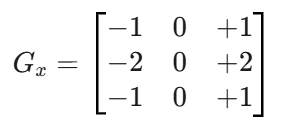 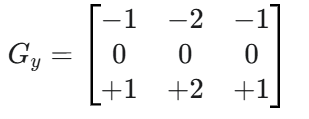

**OJO**
Resaltado horizontal significa que detecta el cambios fuertes de manera horizontal -> resalta lineas verticales.

-->|-->

-->|-->

-->|-->

Resaltado vertical significa que detecta los cambios fuertes de manera vertical -> resalta lineas horizontales

↓ - -  ↓- -   ↓

➖➖➖

↓ - -  ↓- -   ↓


Definición de kernels en python

In [4]:
Gx = np.array([-1,0,1,
      -2,0,2,
      -1,0,1], dtype=np.float32)
Gy = np.array([-1,-2,-1,
       0,0,0,
       1,2,1], dtype=np.float32)

### Ejemplo implementación sobel

Trabajaremos con la siguiente imagen

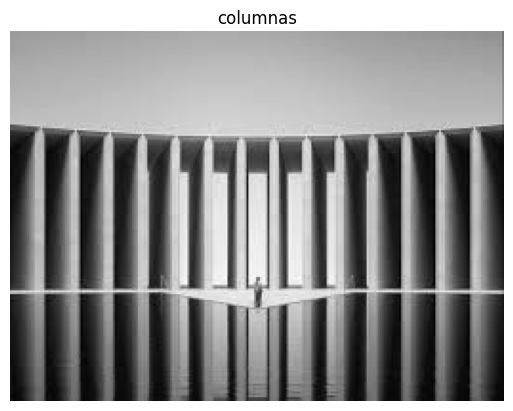

In [5]:
img_columnas_path = './data/columnas.jpg'
columnas = cv2.imread(img_columnas_path)
columnas_gray = cv2.cvtColor(columnas, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(columnas_gray, cmap='gray')
plt.title('columnas')
plt.axis('off')
plt.show()


### Filtro Horizontal Gx

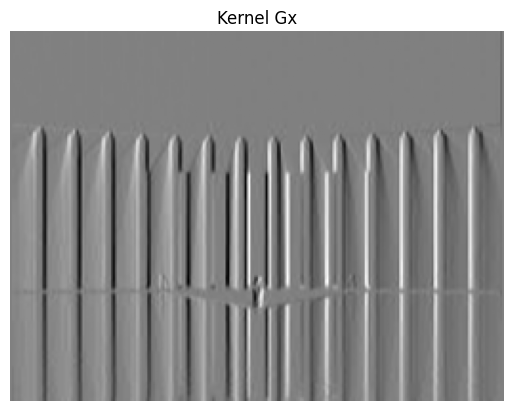

In [6]:
# Aplicamos kernel Gx a imagen para obtener el gradiente horizontal
img_Gx = cv2.filter2D(columnas_gray, cv2.CV_32F, Gx.reshape(3,3))
plt.figure()
plt.imshow(img_Gx, cmap='gray')
plt.title('Kernel Gx')
plt.axis('off')
plt.show()


### Filtro vertical Gy

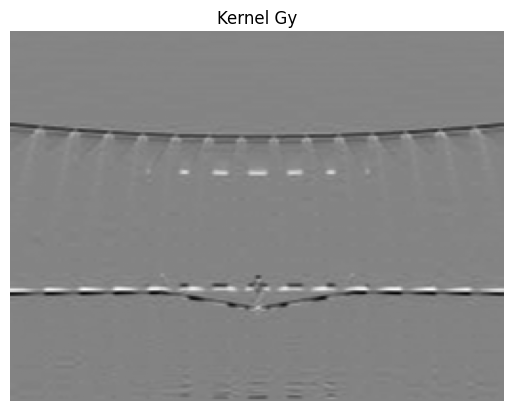

In [7]:
# Aplicamos kernel Gy a imagen para obtener el gradiente vertical
img_Gy = cv2.filter2D(columnas_gray, cv2.CV_32F, Gy.reshape(3,3))
plt.figure()
plt.imshow(img_Gy, cmap='gray')
plt.title('Kernel Gy')
plt.axis('off')
plt.show()

### Calculo de magnitud del gradiente

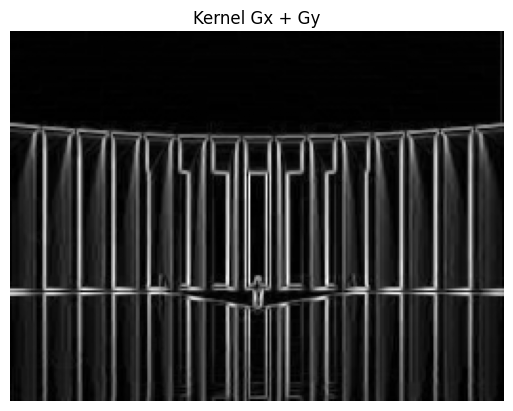

In [8]:
img_columnas_Gx_ = img_Gx.astype(np.float32)
img_columnas_Gy_ = img_Gy.astype(np.float32)

magnitude = np.sqrt(img_columnas_Gx_**2 + img_columnas_Gy_**2)
plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Kernel Gx + Gy')
plt.axis('off')
plt.show()


Falta normalizar

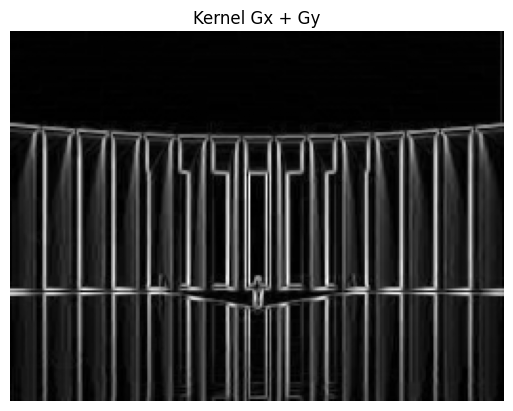

In [9]:
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude = magnitude.astype(np.uint8)

plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Kernel Gx + Gy')
plt.axis('off')
plt.show()




### Aplicación directa con cv2.sobel

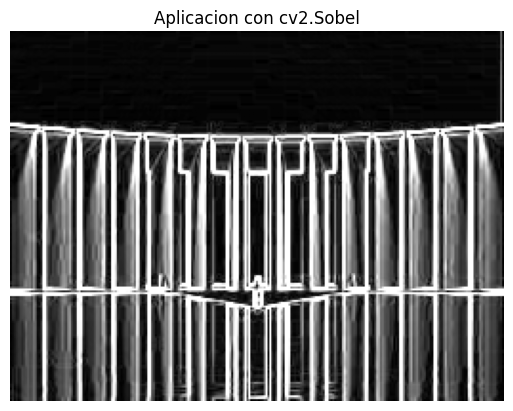

In [10]:
sobel_x = cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0)
sobel_y = cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)

magnitude = cv2.magnitude(sobel_x, sobel_y)
magnitude = cv2.convertScaleAbs(magnitude)

plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Aplicacion con cv2.Sobel')
plt.axis('off')
plt.show()



## Canny

>"El algoritmo de Canny es usado para detectar todos los bordes existentes en una imagen. Este algoritmo esta considerado como uno de los mejores métodos de detección de contornos mediante el empleo de máscaras de convolución y basado en la primera derivada. Los puntos de contorno son como zonas de píxels en las que existe un cambio brusco de nivel de gris." 

Jorge Valverde Rebaza - "Detección de bordes mediante el algoritmo de Canny", 2014. [Link](https://www.cs.buap.mx/~daniel.valdes/docs/Deteccion_de_bordes_mediante_el_algoritmo_de_Canny.pdf)

El algoritmo de Canny consiste en tres grandes pasos:

• Obtención del gradiente: en este paso se calcula la magnitud y orientación del vector
gradiente en cada píxel.

• Supresión no máxima: en este paso se logra el adelgazamiento del ancho de los bordes,
obtenidos con el gradiente, hasta lograr bordes de un píxel de ancho.

• Histéresis de umbral: en este paso se aplica una función de histéresis basada en dos
umbrales; con este proceso se pretende reducir la posibilidad de aparición de contornos
falsos. ``

Jorge Valverde Rebaza - "Detección de bordes mediante el algoritmo de Canny", 2014. [Link](https://www.cs.buap.mx/~daniel.valdes/docs/Deteccion_de_bordes_mediante_el_algoritmo_de_Canny.pdf)

### Obtención del gradiente

Para la obtención del gradiente, como paso previo, se aplica un filtro gaussiano para suavizar la imagen original y evitar que el posible ruido cree bordes falsos en pasos siguientes.

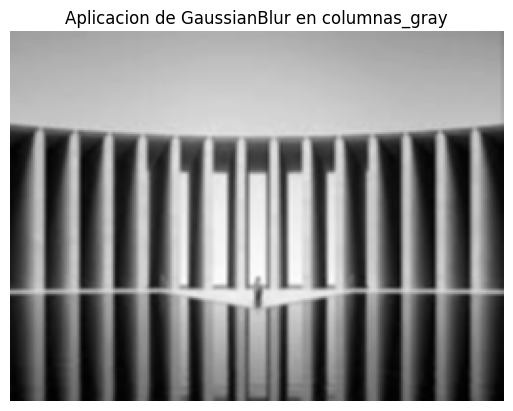

In [95]:
gauss_columnas_gray = cv2.GaussianBlur(columnas_gray, (3,3),1)
plt.figure()
plt.imshow(gauss_columnas_gray, cmap='gray')
plt.title('Aplicacion de GaussianBlur en columnas_gray')
plt.axis('off')
plt.show()

Luego, para cada píxel, se obtiene la magnitud y módulo (orientación) del gradiente, obteniendo dos imágenes 

# Consigna Sobel / Canny

Remarca los ladrillos en la siguiente foto "ladrillos.jpg".

Luego cuenta la cantidad de ladrillos (de manera aproximada, no es necesario que de exacto).

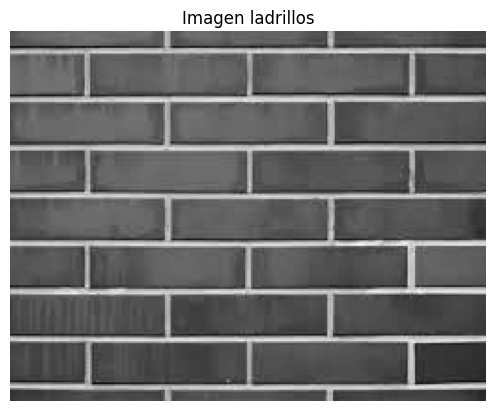

In [13]:
ladrillos = cv2.imread('./data/ladrillos.jpg')
ladrillos_gray = cv2.cvtColor(ladrillos, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(ladrillos_gray, cmap='gray')
plt.title('Imagen ladrillos')
plt.axis('off')
plt.show()

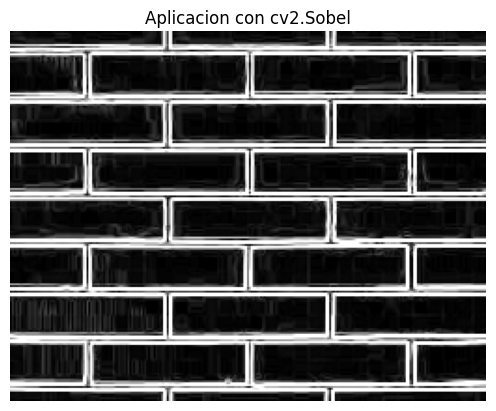

In [14]:
sobel_x = cv2.Sobel(ladrillos_gray, cv2.CV_32F, 1, 0)
sobel_y = cv2.Sobel(ladrillos_gray, cv2.CV_32F, 0, 1)

magnitude_ladrillos = cv2.magnitude(sobel_x, sobel_y)
magnitude_ladrillos = cv2.convertScaleAbs(magnitude_ladrillos)

plt.figure()
plt.imshow(magnitude_ladrillos, cmap='gray')
plt.title('Aplicacion con cv2.Sobel')
plt.axis('off')
plt.show()

## Posible solucion 

In [87]:
# Normalizar a 8 bits
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Umbral binario
_, bin_x = cv2.threshold(sobel_x, 160, 255, cv2.THRESH_BINARY)
_, bin_y = cv2.threshold(sobel_y, 160, 255, cv2.THRESH_BINARY)

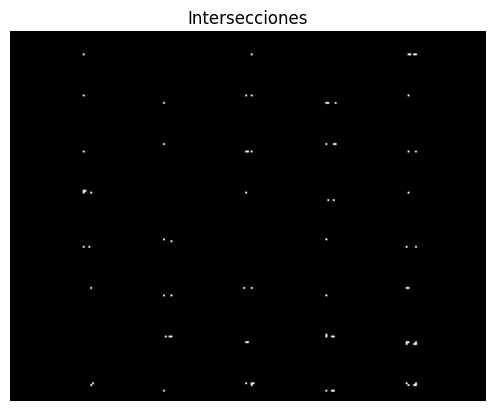

In [88]:
intersecciones = cv2.bitwise_and(bin_x, bin_y)

plt.imshow(intersecciones, cmap='gray')
plt.title("Intersecciones")
plt.axis('off')
plt.show()

In [89]:
num_labels, labels = cv2.connectedComponents(intersecciones)

# Restamos 1 porque el fondo cuenta como etiqueta
num_intersecciones = num_labels - 1

print("Número de intersecciones:", num_intersecciones)

Número de intersecciones: 54


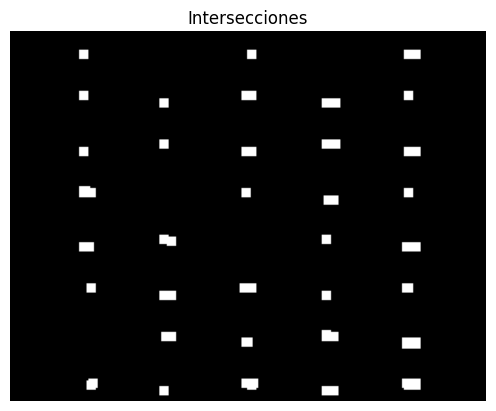

In [90]:
kernel = np.ones((5,5), np.uint8)
intersecciones_close = cv2.morphologyEx(intersecciones, cv2.MORPH_DILATE, kernel)

plt.imshow(intersecciones_close, cmap='gray')
plt.title("Intersecciones")
plt.axis('off')
plt.show()


In [91]:
num_labels_close, labels = cv2.connectedComponents(intersecciones_close)

# Restamos 1 porque el fondo cuenta como etiqueta
num_intersecciones_close = num_labels_close - 1

print("Número de intersecciones:", num_intersecciones_close)

Número de intersecciones: 35
